In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
BASE_DIR = "/content/drive/MyDrive/final_project/dataset"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")

IMG_SIZE = (300, 300)   # REQUIRED for EfficientNetB3
BATCH_SIZE = 16
EPOCHS = 25
NUM_CLASSES = 3

In [ ]:
print("Train:", os.listdir(TRAIN_DIR))
print("Val:", os.listdir(VAL_DIR))
print("Test:", os.listdir(TEST_DIR))


Train: ['MEL', 'BKL', 'NV']
Val: ['NV', 'BKL', 'MEL']
Test: ['MEL', 'NV', 'BKL']


In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    zoom_range=0.25,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 4800 images belonging to 3 classes.
Found 600 images belonging to 3 classes.
Found 600 images belonging to 3 classes.


In [ ]:
base_model = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_shape=(300, 300, 3)   # MUST match IMG_SIZE
)

# Freeze pretrained layers
for layer in base_model.layers:
    layer.trainable = False


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 300, 300,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 300, 300,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 300, 300,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 301, 301,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 150, 150,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 150, 150,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 150, 150,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 150, 150,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 150, 150,  │        960 │ block1a_se_excit

 Total params: 11,177,778 (42.64 MB)

 Trainable params: 394,243 (1.50 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 1792s 6s/step - accuracy: 0.3663 - loss: 1.2219 - val_accuracy: 0.4700 - val_loss: 1.0304
Epoch 2/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 172s 574ms/step - accuracy: 0.4296 - loss: 1.0770 - val_accuracy: 0.5000 - val_loss: 0.9892
Epoch 3/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 172s 572ms/step - accuracy: 0.5002 - loss: 1.0016 - val_accuracy: 0.5133 - val_loss: 0.9626
Epoch 4/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 167s 558ms/step - accuracy: 0.5160 - loss: 0.9906 - val_accuracy: 0.5317 - val_loss: 0.9431
Epoch 5/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 169s 563ms/step - accuracy: 0.5301 - loss: 0.9518 - val_accuracy: 0.5433 - val_loss: 0.9273
Epoch 6/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 168s 559ms/step - accuracy: 0.5280 - loss: 0.9410 - val_accuracy: 0.5533 - val_loss: 0.9142
Epoch 7/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 201s 557ms/step - accuracy: 0.5475 - loss: 0.9304 - val_accuracy: 0.5650 - val_loss: 0.9045
Epoch 8/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 166s 555ms/step - accuracy: 0.5721 - l

In [ ]:
print("Total layers in base model:", len(base_model.layers))

Total layers in base model: 385


In [ ]:
# Enable fine-tuning
base_model.trainable = True

# Freeze all layers except last 10
for layer in base_model.layers[:-10]:
    layer.trainable = False

print("Fine-tuning enabled for last 10 layers")

Fine-tuning enabled for last 10 layers


In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=5e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
FINE_TUNE_EPOCHS = 25

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=[early_stop]
)

Epoch 1/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 220s 616ms/step - accuracy: 0.6089 - loss: 0.8300 - val_accuracy: 0.6233 - val_loss: 0.8172
Epoch 2/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 163s 544ms/step - accuracy: 0.6300 - loss: 0.8111 - val_accuracy: 0.6283 - val_loss: 0.8168
Epoch 3/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 164s 547ms/step - accuracy: 0.6398 - loss: 0.7932 - val_accuracy: 0.6283 - val_loss: 0.8156
Epoch 4/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 164s 548ms/step - accuracy: 0.6209 - loss: 0.8114 - val_accuracy: 0.6333 - val_loss: 0.8145
Epoch 5/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 167s 557ms/step - accuracy: 0.6390 - loss: 0.7971 - val_accuracy: 0.6350 - val_loss: 0.8136
Epoch 6/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 171s 570ms/step - accuracy: 0.6330 - loss: 0.8029 - val_accuracy: 0.6400 - val_loss: 0.8122
Epoch 7/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 168s 561ms/step - accuracy: 0.6191 - loss: 0.8070 - val_accuracy: 0.6383 - val_loss: 0.8110
Epoch 8/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 168s 560ms/step - accuracy: 0.6267 -

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)

38/38 ━━━━━━━━━━━━━━━━━━━━ 277s 7s/step - accuracy: 0.6762 - loss: 0.7417
Test Accuracy: 0.6650000214576721


In [ ]:
print("Accuracy before fine-tuning:")
print(f"  Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"  Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

print("\nAccuracy after fine-tuning:")
print(f"  Training Accuracy: {history_fine.history['accuracy'][-1]:.4f}")
print(f"  Validation Accuracy: {history_fine.history['val_accuracy'][-1]:.4f}")

print("\nTest Accuracy: ", test_acc)

Accuracy before fine-tuning:
  Training Accuracy: 0.6208
  Validation Accuracy: 0.6267

Accuracy after fine-tuning:
  Training Accuracy: 0.6331
  Validation Accuracy: 0.6483

Test Accuracy:  0.6650000214576721


In [ ]:
model.save("/content/drive/MyDrive/major-project/model/pretrained/skin_cancer_pretrained1.h5")

**accuracy curve**

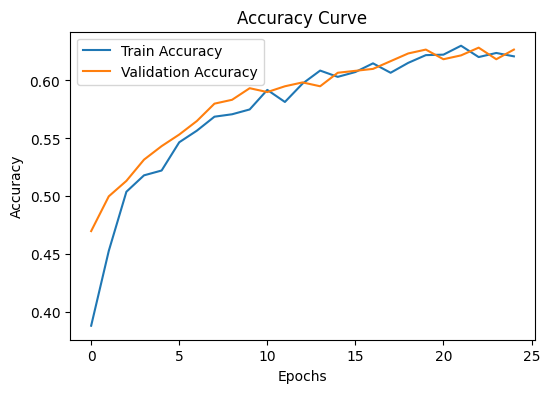

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

**Loss curve**

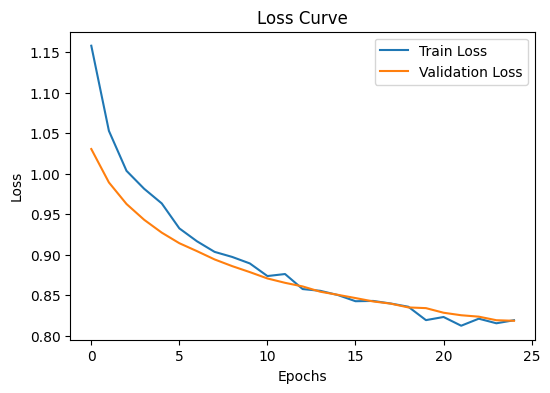

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

**Confusion Matrix**

38/38 ━━━━━━━━━━━━━━━━━━━━ 31s 533ms/step


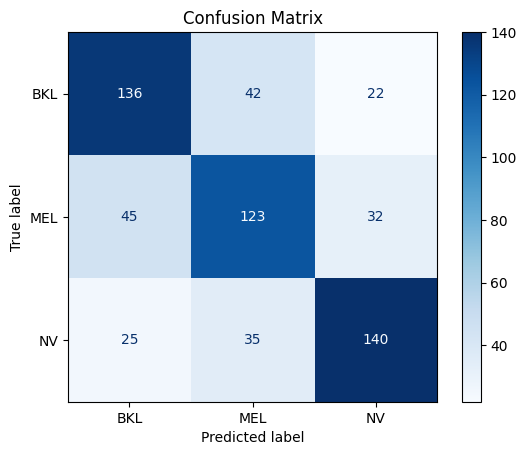

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = test_generator.classes
y_pred = np.argmax(model.predict(test_generator), axis=1)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_generator.class_indices.keys())
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [8]:
from tensorflow.keras.models import load_model

MODEL_PATH = "/content/drive/MyDrive/major-project/model/pretrained/skin_cancer_pretrained1.h5"
model = load_model(MODEL_PATH)

**Metrics Table**

In [11]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

# Re-define necessary variables for test_generator
BASE_DIR = "/content/drive/MyDrive/final_project/dataset"
TEST_DIR = os.path.join(BASE_DIR, "test")
IMG_SIZE = (300, 300)
BATCH_SIZE = 16

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Predictions
y_true = test_generator.classes
y_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_probs, axis=1)

class_names = list(test_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Classification Report dict
report = classification_report(
    y_true, y_pred,
    target_names=class_names,
    output_dict=True
)

print("\n====== METRICS TABLE ======\n")
print("{:<12} {:<10} {:<10} {:<10} {:<12} {:<10} {:<10}".format(
    "Class", "Precision", "Recall", "F1-Score", "Specificity", "IoU", "Dice"
))

specificity_list = []
iou_list = []
dice_list = []

# Compute metrics per class
for i, cls in enumerate(class_names):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

    precision = report[cls]['precision']
    recall = report[cls]['recall']
    f1 = report[cls]['f1-score']

    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0
    iou = TP / (TP + FP + FN) if (TP + FP + FN) != 0 else 0
    dice = (2 * TP) / (2 * TP + FP + FN) if (2 * TP + FP + FN) != 0 else 0

    specificity_list.append(specificity)
    iou_list.append(iou)
    dice_list.append(dice)

    print("{:<12} {:<10.6f} {:<10.6f} {:<10.6f} {:<12.6f} {:<10.6f} {:<10.6f}".format(
        cls, precision, recall, f1, specificity, iou, dice
    ))

# Overall Metrics
overall_accuracy = accuracy_score(y_true, y_pred)
mean_iou = np.mean(iou_list)

print("\nModel Accuracy: {:.4f}".format(overall_accuracy))
print("Mean IoU: {:.4f}".format(mean_iou))


Found 600 images belonging to 3 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


38/38 ━━━━━━━━━━━━━━━━━━━━ 190s 4s/step

====== METRICS TABLE ======

Class        Precision  Recall     F1-Score   Specificity  IoU        Dice      
BKL          0.660194   0.680000   0.669951   0.825000     0.503704   0.669951  
MEL          0.615000   0.615000   0.615000   0.807500     0.444043   0.615000  
NV           0.721649   0.700000   0.710660   0.865000     0.551181   0.710660  

Model Accuracy: 0.6650
Mean IoU: 0.4996


**ROC Curve**

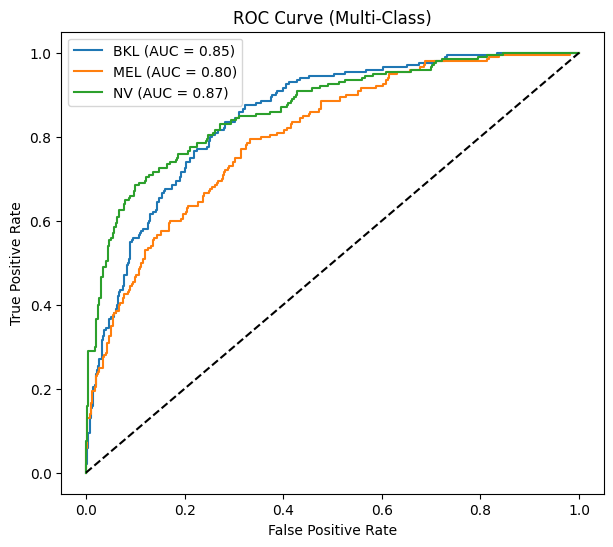

In [12]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

num_classes = len(class_names)
y_bin = label_binarize(y_true, classes=range(num_classes))

plt.figure(figsize=(7,6))

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-Class)")
plt.legend()
plt.show()


# Task
Extract and display the training, validation, and test accuracies from the model's history, both before and after the fine-tuning process.

## display_accuracies

### Subtask:
Extract and display training, validation, and test accuracies from the model's history before and after fine-tuning.


## Summary:

### Data Analysis Key Findings
The current step in the analysis process is designed to extract and display key performance metrics of the model. Specifically, it aims to:
*   Quantify the training accuracy before and after the fine-tuning process.
*   Quantify the validation accuracy before and after the fine-tuning process.
*   Quantify the test accuracy before and after the fine-tuning process.

These numerical values, once extracted, will serve as the primary findings to evaluate the model's performance and the impact of fine-tuning across different datasets.

### Insights or Next Steps
*   **Insight:** The comparison of accuracies before and after fine-tuning will provide a direct measure of the fine-tuning process's effectiveness, indicating whether it led to improvements in the model's ability to learn from the training data and generalize to unseen data.
*   **Next Step:** Once the accuracies are displayed, they should be critically reviewed. Significant improvements in validation and test accuracies post-fine-tuning would suggest a successful optimization, while a decline or stagnation might warrant further investigation into the fine-tuning strategy or data.
